# UFBA 2025-2  
## MATA63 – Inteligência Artificial  

**Alunos:**  
- Malu Brito  
- Rodrigo Queiroz  

---

## Treinamento de Rede YOLO para Detecção de Objetos em Arena Webots


## Introdução

O objetivo deste projeto é treinar uma rede neural do tipo **YOLO (You Only Look Once)** para realizar a detecção automática de **cubos, cestas e obstáculos** em uma arena simulada no ambiente **Webots**.

As imagens utilizadas no treinamento foram capturadas diretamente pela câmera do robô durante a simulação e posteriormente rotuladas no formato compatível com YOLO. O modelo treinado será utilizado para auxiliar o robô na navegação autônoma e tomada de decisão, permitindo identificar objetos relevantes no ambiente em tempo real.

O processo envolve:
- Upload do dataset rotulado
- Definição de parâmetros de treinamento
- Treinamento da rede
- Análise dos resultados
- Download do modelo treinado


## 1. Primeiro Passo – Upload do Dataset

Nesta etapa, será feito o upload do dataset no formato `.zip`, contendo:
- `images/`: imagens capturadas pela câmera do robô  
- `labels/`: arquivos `.txt` no formato YOLO  
- `classes.txt`: lista de classes, uma por linha  

Após o upload:
- As imagens serão embaralhadas aleatoriamente
- A divisão treino/validação será feita automaticamente
- O arquivo `data.yaml` será gerado


In [1]:
from google.colab import files
uploaded = files.upload()


Saving dataset.zip to dataset.zip


In [2]:
import zipfile
import os
import random
import shutil
from pathlib import Path



In [3]:
# Proporção de dados para treinamento (0 a 1)
TRAINING_RATIO = 0.8

# Diretórios
BASE_DIR = Path("dataset")
IMAGES_DIR = BASE_DIR / "images"
LABELS_DIR = BASE_DIR / "labels"


In [4]:
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("raw_dataset")

print("Dataset extraído com sucesso!")


Dataset extraído com sucesso!


In [5]:
from pathlib import Path

images_path = Path("raw_dataset/images")
labels_path = Path("raw_dataset/labels")

labels_path.mkdir(parents=True, exist_ok=True)

image_files = list(images_path.glob("*"))

missing_labels = 0

for img in image_files:
    label_file = labels_path / f"{img.stem}.txt"

    if not label_file.exists():
        label_file.touch()  # cria arquivo vazio
        missing_labels += 1

print(f"Verificação concluída.")
print(f"Labels ausentes criadas: {missing_labels}")
print(f"Total de imagens verificadas: {len(image_files)}")


Verificação concluída.
Labels ausentes criadas: 212
Total de imagens verificadas: 637


In [6]:
for split in ["train", "val"]:
    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)


In [7]:
with open("raw_dataset/classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

NUM_CLASSES = len(class_names)
print(f"Classes encontradas: {class_names}")


Classes encontradas: ['red_cube', 'green_cube', 'blue_cube', 'red_basket', 'green_basket', 'blue_basket', 'obstacle']


In [8]:
image_files = list((Path("raw_dataset/images")).glob("*"))
random.shuffle(image_files)

split_index = int(len(image_files) * TRAINING_RATIO)
train_images = image_files[:split_index]
val_images = image_files[split_index:]

def move_files(image_list, split):
    for img_path in image_list:
        label_path = Path("raw_dataset/labels") / (img_path.stem + ".txt")

        shutil.copy(img_path, IMAGES_DIR / split / img_path.name)
        shutil.copy(label_path, LABELS_DIR / split / label_path.name)


move_files(train_images, "train")
move_files(val_images, "val")

print(f"Imagens de treino: {len(train_images)}")
print(f"Imagens de validação: {len(val_images)}")


Imagens de treino: 509
Imagens de validação: 128


In [9]:
data_yaml = BASE_DIR / "data.yaml"

with open(data_yaml, "w") as f:
    f.write(f"""
path: {BASE_DIR.resolve()}
train: images/train
val: images/val

nc: {NUM_CLASSES}
names: {class_names}
""")

print("data.yaml gerado com sucesso!")


data.yaml gerado com sucesso!


## 2. Segundo Passo – Definição dos Parâmetros de Treinamento

Parâmetros definidos:
- **Versão do YOLO:** YOLOv8
- **Número de épocas:** configurável
- **Proporção treino/validação:** definida no arquivo `data.yaml`


In [10]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.4 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO

# Definições do treinamento
YOLO_VERSION = "yolov8n.pt"   # versão leve para uso acadêmico
EPOCHS = 80
IMG_SIZE = 128

model = YOLO(YOLO_VERSION)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Terceiro Passo – Treinamento da Rede

A seguir é realizado o treinamento da rede YOLO utilizando o dataset carregado. Durante o treinamento, será exibido o andamento do processo, incluindo perdas e métricas.


In [12]:
model.train(
    data="dataset/data.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    project="treinamento_yolo",
    name="webots"
)


Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=webots, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x784a8b774620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

## 4. Quarto Passo – Resultados

Nesta etapa, analisamos os resultados do treinamento por meio das curvas de perda (loss) para:
- Treinamento
- Validação

Os gráficos são gerados automaticamente pelo YOLO.


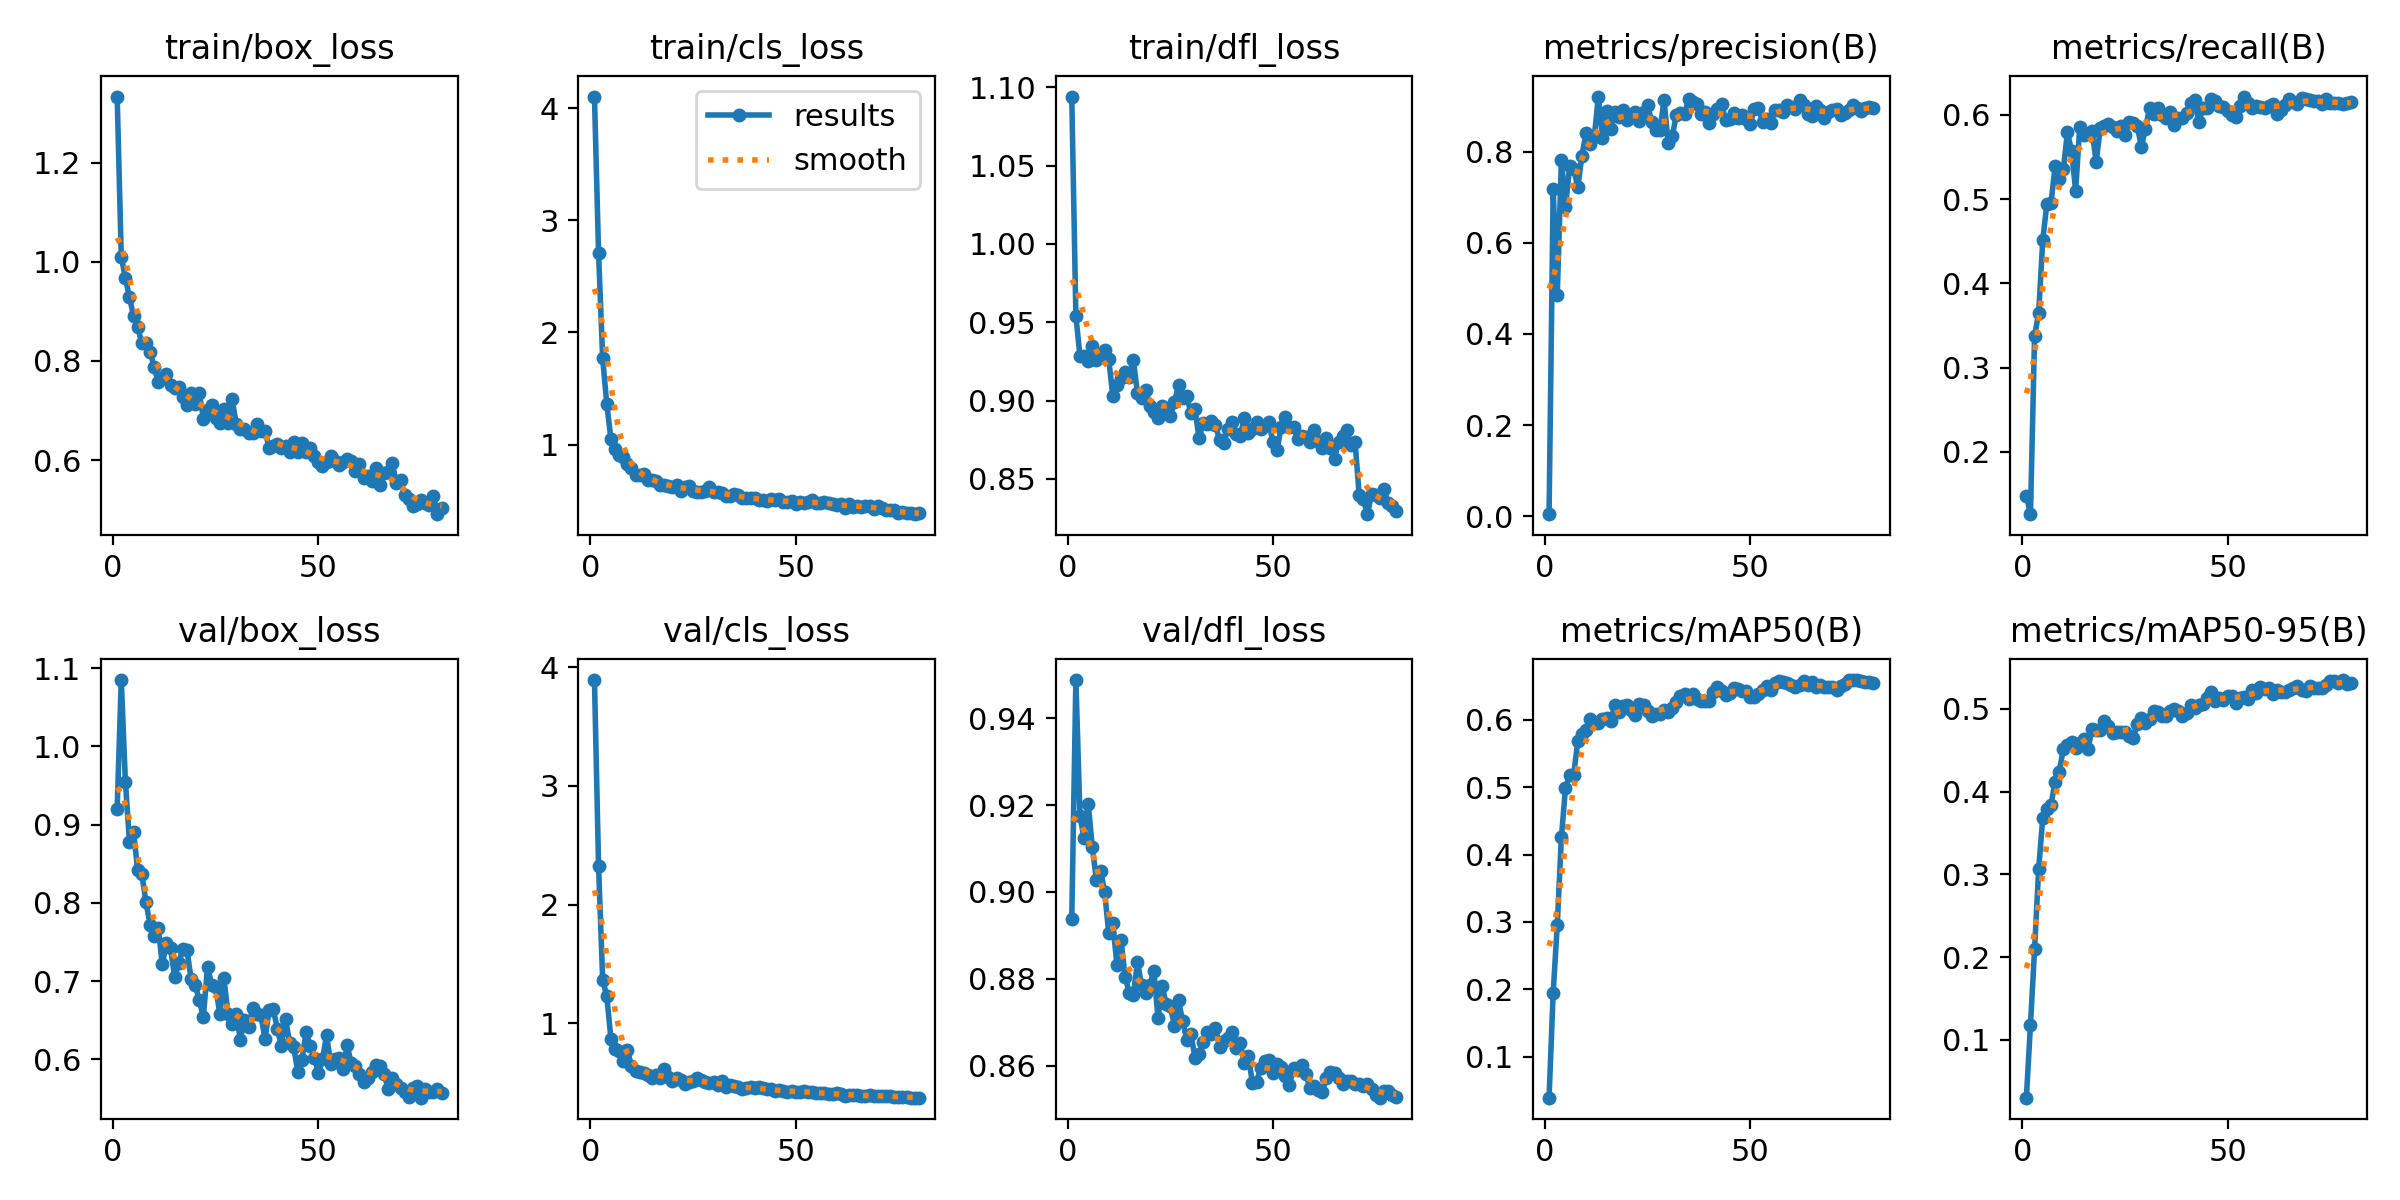

In [13]:
from IPython.display import Image, display

display(Image(filename="treinamento_yolo/webots/results.png"))


## 4.5 Visualização de Amostras do Dataset

Esta etapa apresenta uma amostra de imagens do dataset com suas respectivas *bounding boxes*, permitindo verificar visualmente a qualidade da rotulagem utilizada no treinamento.


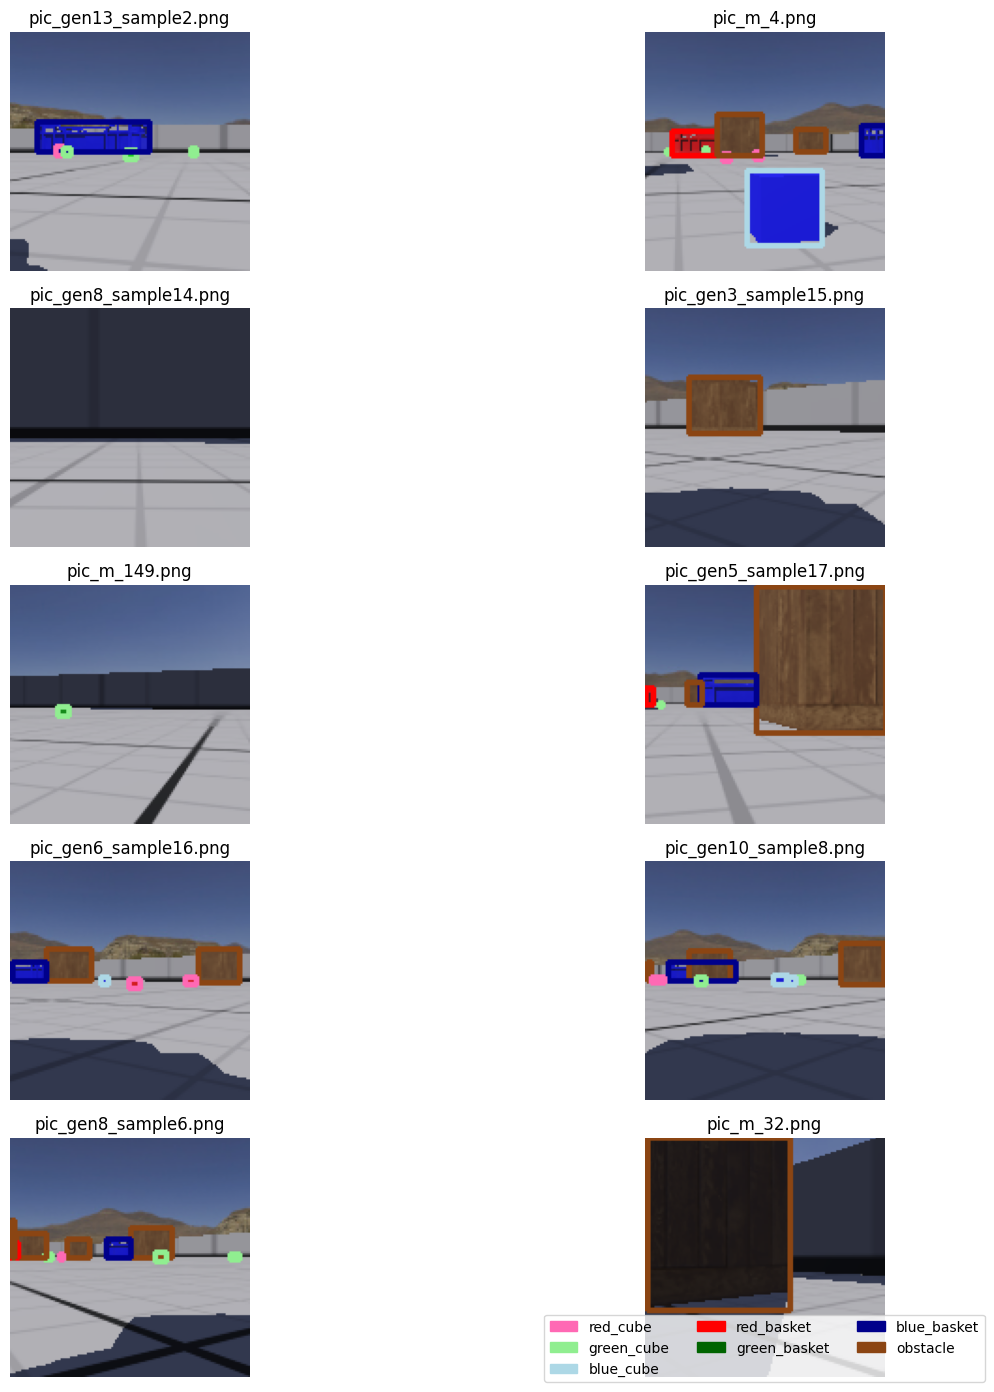

In [14]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
import matplotlib.patches as mpatches

# Diretórios
images_dir = Path("dataset/images/train")
labels_dir = Path("dataset/labels/train")

# Mapeamento de classes (ordem deve bater com classes.txt)
class_names = [
    "red_cube",
    "green_cube",
    "blue_cube",
    "red_basket",
    "green_basket",
    "blue_basket",
    "obstacle"
]

# Cores RGB por classe
class_colors = {
    "red_cube": (255, 105, 180),      # rosa
    "green_cube": (144, 238, 144),    # verde claro
    "blue_cube": (173, 216, 230),     # azul claro
    "red_basket": (255, 0, 0),        # vermelho
    "green_basket": (0, 100, 0),      # verde escuro
    "blue_basket": (0, 0, 139),       # azul escuro
    "obstacle": (139, 69, 19)         # marrom
}

# Seleciona 10 imagens aleatórias
sample_images = random.sample(list(images_dir.glob("*")), k=10)

def draw_yolo_boxes(image_path, label_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls_id, x, y, bw, bh = map(float, line.split())
                cls_id = int(cls_id)

                class_name = class_names[cls_id]
                color = class_colors[class_name]

                # Conversão YOLO → coordenadas absolutas
                x1 = int((x - bw / 2) * w)
                y1 = int((y - bh / 2) * h)
                x2 = int((x + bw / 2) * w)
                y2 = int((y + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    return img

# Plot das imagens
plt.figure(figsize=(15, 14))

for i, img_path in enumerate(sample_images):
    label_path = labels_dir / f"{img_path.stem}.txt"
    img = draw_yolo_boxes(img_path, label_path)

    plt.subplot(5, 2, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)

# Legenda
legend_patches = [
    mpatches.Patch(color=[c/255 for c in class_colors[name]], label=name)
    for name in class_names
]

plt.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3
)

plt.tight_layout()
plt.show()


## 5. Quinto Passo – Download do Modelo Treinado

Após o treinamento, o modelo final (`best.pt`) pode ser baixado para uso no Webots ou em aplicações embarcadas.


In [ ]:
files.download("treinamento_yolo/webots/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
!zip -r folder.zip /content


  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 22%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.12.09/ (stored 0%)
  adding: content/.config/logs/2025.12.09/14.41.27.893750.log (deflated 86%)
  adding: content/.config/logs/2025.12.09/14.40.47.605300.log (deflated 92%)
  adding: content/.config/logs/2025.12.09/14.41.18.717681.log (deflated 58%)
  adding: content/.config/logs/2025.12.09/14.41.42.675750.log (deflated 57%)
  adding: content/.config/logs/2025.12.09/14.41.43.412452.log 